Getting environment ready

In [6]:
!unrar x Imgs.rar dataset/

Streaming output truncated to the last 5000 lines.
Extracting  dataset/Imgs/130822.jpg                                       16%  OK 
Extracting  dataset/Imgs/130822.png                                       16%  OK 
Extracting  dataset/Imgs/13084.jpg                                        16%  OK 
Extracting  dataset/Imgs/13084.png                                        16%  OK 
Extracting  dataset/Imgs/13085.jpg                                        16%  OK 
Extracting  dataset/Imgs/13085.png                                        16%  OK 
Extracting  dataset/Imgs/130851.jpg                                       16%  OK 
Extracting  dataset/Imgs/130851.png                                       16%  OK 
Extracting  dataset/Imgs/130855.jpg                                       16%  OK 
Extracting  dataset/Imgs/130855.png                                       16%  OK 
Extracting  dataset/Imgs/1308

In [7]:
import os
files = os.listdir('dataset/Imgs')
jpgs = [f for f in files if f.endswith('.jpg')]
pngs = [f for f in files if f.endswith('.png')]

print(f"Healthy JPGs: {len(jpgs)}")
print(f"Healthy PNGs: {len(pngs)}")

Healthy JPGs: 4122
Healthy PNGs: 4122


In [8]:
import os

path = 'dataset/Imgs/'

# List the first 10 files
files = os.listdir(path)
print(f"Total files found: {len(files)}")
print(files[:10])

Total files found: 8244
['140567.png', '111980.jpg', '144287.jpg', '104730.jpg', '133414.png', '146403.jpg', '12780.jpg', '103048.png', '160553.jpg', '151334.jpg']


EDA(Exploratory Data Analysis) - Make sure the mask matches

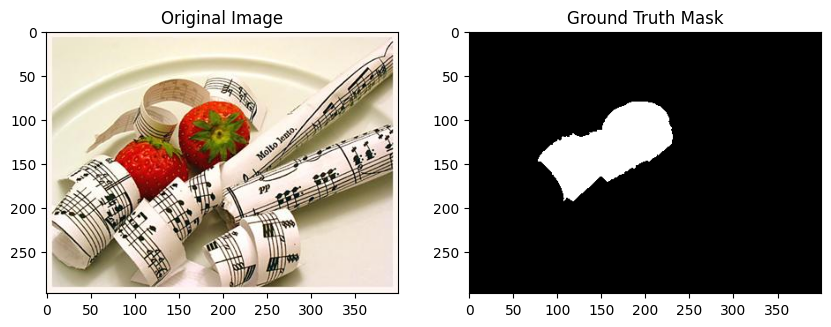

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Using a sample
sample_id = '108284'
img_path = f'dataset/Imgs/{sample_id}.jpg'
mask_path = f'dataset/Imgs/{sample_id}.png'

# Load the image and the mask
img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

# Displaying them
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='gray')
plt.title("Ground Truth Mask")
plt.show()

In [9]:
import glob

# Get all jpg files and sort them to ensure they match their masks
all_images = sorted(glob.glob('dataset/Imgs/*.jpg'))
all_masks = sorted(glob.glob('dataset/Imgs/*.png'))

print(f"Number of image-mask pairs: {len(all_images)}")

# Check if the first pair matches
print(f"First Image: {all_images[0]}")
print(f"First Mask: {all_masks[0]}")

Number of image-mask pairs: 4122
First Image: dataset/Imgs/100015.jpg
First Mask: dataset/Imgs/100015.png


Resizing and Normalisation

In [11]:
import cv2
import numpy as np

def load_and_preprocess(image_path, mask_path, target_size=(128, 128)):
    # Load image and resize
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)

    # Load mask, resize, and keep it 1-channel
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, target_size)

    # Normalization (scale pixel values to 0-1)
    img = img.astype('float32') / 255.0
    mask = mask.astype('float32') / 255.0

    # Add a channel dimension to the mask (making it 128x128x1)
    mask = np.expand_dims(mask, axis=-1)

    return img, mask

# Test the function on the first pair
test_img, test_mask = load_and_preprocess(all_images[0], all_masks[0])
print(f"Resized Image Shape: {test_img.shape}")
print(f"Resized Mask Shape: {test_mask.shape}")
print(f"Max pixel value after normalization: {test_img.max()}")

Resized Image Shape: (128, 128, 3)
Resized Mask Shape: (128, 128, 1)
Max pixel value after normalization: 1.0


Splitting the data

In [12]:
from sklearn.model_selection import train_test_split

# First, separate out the Test set (15% of total)
train_imgs, test_imgs, train_masks, test_masks = train_test_split(
    all_images, all_masks, test_size=0.15, random_state=42
)

# Second, split the remaining 85% into Train and Validation
# 0.176 approx results in 15% of the original total for validation
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    train_imgs, train_masks, test_size=0.176, random_state=42
)

print(f"Training pairs: {len(train_imgs)}")
print(f"Validation pairs: {len(val_imgs)}")
print(f"Testing pairs: {len(test_imgs)}")

Training pairs: 2886
Validation pairs: 617
Testing pairs: 619


Data Pipeline

In [13]:
#Implementing a lazy loading approach to maintain a low memory footprint during training

def data_generator(image_paths, mask_paths, batch_size=16):
    while True:
        for i in range(0, len(image_paths), batch_size):
            batch_img_paths = image_paths[i:i+batch_size]
            batch_mask_paths = mask_paths[i:i+batch_size]

            X, Y = [], []
            for img_p, mask_p in zip(batch_img_paths, batch_mask_paths):
                img, mask = load_and_preprocess(img_p, mask_p)
                X.append(img)
                Y.append(mask)

            yield np.array(X), np.array(Y)

# Initialize the generators
train_gen = data_generator(train_imgs, train_masks, batch_size=16)
val_gen = data_generator(val_imgs, val_masks, batch_size=16)

# Test if the generator works
x_test, y_test = next(train_gen)
print(f"Batch X shape: {x_test.shape}") # Should be (16, 128, 128, 3)
print(f"Batch Y shape: {y_test.shape}") # Should be (16, 128, 128, 1)

Batch X shape: (16, 128, 128, 3)
Batch Y shape: (16, 128, 128, 1)


The model - Encoder Decoder CNN

In [14]:
from tensorflow.keras import layers, models

def build_model(input_shape=(128, 128, 3)):
    inputs = layers.Input(input_shape)

    # Encoder (Downsampling)
    conv1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    pool1 = layers.MaxPooling2D((2, 2))(conv1) # Size: 64x64

    conv2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(pool1)
    pool2 = layers.MaxPooling2D((2, 2))(conv2) # Size: 32x32

    # Bottleneck
    conv3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(pool2)

    # Decoder (Upsampling)
    up1 = layers.UpSampling2D((2, 2))(conv3) # Size: 64x64
    conv4 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(up1)

    up2 = layers.UpSampling2D((2, 2))(conv4) # Size: 128x128
    conv5 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(up2)

    # Output Layer (1 channel for the mask, Sigmoid for 0-1 values)
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(conv5)

    model = models.Model(inputs, outputs)
    return model

# Create the model and check the summary
model = build_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 1)    │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,537 (724.75 KB)

 Trainable params: 185,537 (724.75 KB)

 Non-trainable params: 0 (0.00 B)

Compiling and Training

In [23]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Set how many steps to take per epoch
train_steps = len(train_imgs) // 16
val_steps = len(val_imgs) // 16

# Start training
history = model.fit(
    train_gen,
    steps_per_epoch=train_steps,
    validation_data=val_gen,
    validation_steps=val_steps,
    epochs=10  # Start with 10
)

Epoch 1/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 471s 3s/step - accuracy: 0.7830 - loss: 0.4419 - val_accuracy: 0.7968 - val_loss: 0.4024
Epoch 2/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 468s 3s/step - accuracy: 0.8111 - loss: 0.3792 - val_accuracy: 0.8122 - val_loss: 0.3842
Epoch 3/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 500s 3s/step - accuracy: 0.8174 - loss: 0.3690 - val_accuracy: 0.8208 - val_loss: 0.3555
Epoch 4/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 464s 3s/step - accuracy: 0.8214 - loss: 0.3637 - val_accuracy: 0.8254 - val_loss: 0.3503
Epoch 5/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 502s 3s/step - accuracy: 0.8261 - loss: 0.3566 - val_accuracy: 0.8233 - val_loss: 0.3531
Epoch 6/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 464s 3s/step - accuracy: 0.8261 - loss: 0.3562 - val_accuracy: 0.8295 - val_loss: 0.3471
Epoch 7/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 471s 3s/step - accuracy: 0.8286 - loss: 0.3515 - val_accuracy: 0.8305 - val_loss: 0.3433
Epoch 8/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 471s 3s/step - accuracy: 0.8307 - loss: 0.3482 - val_accu

Visualising results

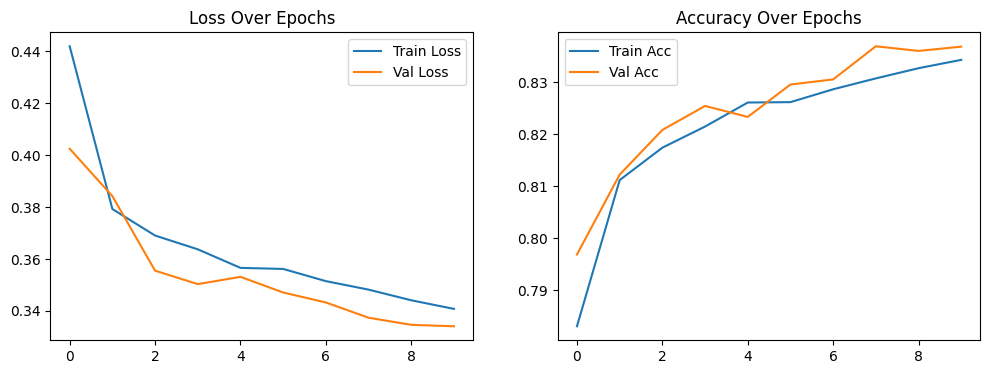

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step


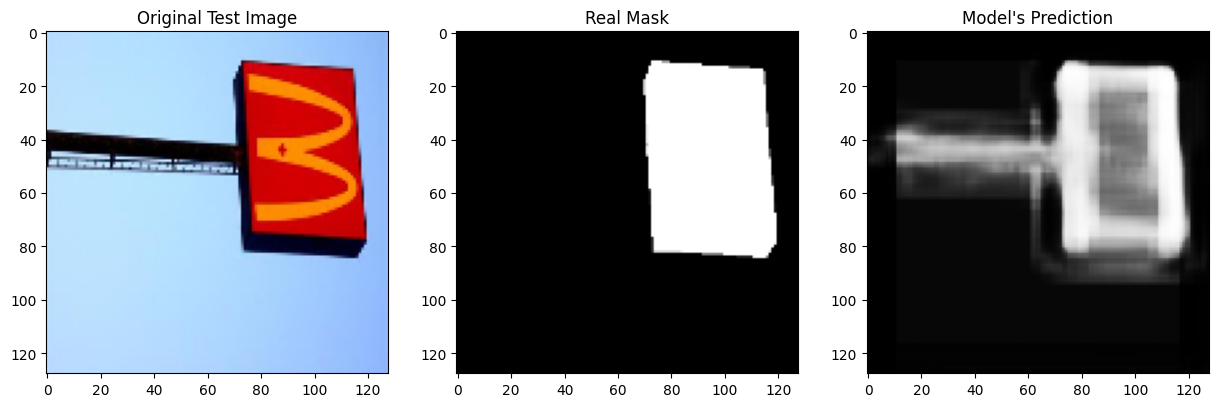

In [25]:
import matplotlib.pyplot as plt

# 1. Plot the Learning Curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy Over Epochs')
plt.legend()
plt.show()

# 2. Predict on a Test Image
test_idx = 10  # Different results when number is changed
img, mask = load_and_preprocess(test_imgs[test_idx], test_masks[test_idx])
prediction = model.predict(np.expand_dims(img, axis=0))[0]

# 3. Show Result
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original Test Image")
plt.subplot(1, 3, 2)
plt.imshow(mask.reshape(128,128), cmap='gray')
plt.title("Real Mask")
plt.subplot(1, 3, 3)
plt.imshow(prediction.reshape(128,128), cmap='gray')
plt.title("Model's Prediction")
plt.show()

Evaluation

In [26]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
# Create a generator for the test set
test_gen = data_generator(test_imgs, test_masks, batch_size=16)
test_steps = len(test_imgs) // 16

# Evaluate the model
results = model.evaluate(test_gen, steps=test_steps)
print(f"Test Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1]:.4f}")

# Save your model so you don't lose your 30 minutes of work!
model.save('salient_object_model.h5')
print("Model saved as salient_object_model.h5")

38/38 ━━━━━━━━━━━━━━━━━━━━ 26s 676ms/step - accuracy: 0.8287 - loss: 0.3454


Test Loss: 0.3454
Test Accuracy: 0.8287
Model saved as salient_object_model.h5


Select an image from your computer:


Saving 124.jpg to 124 (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step


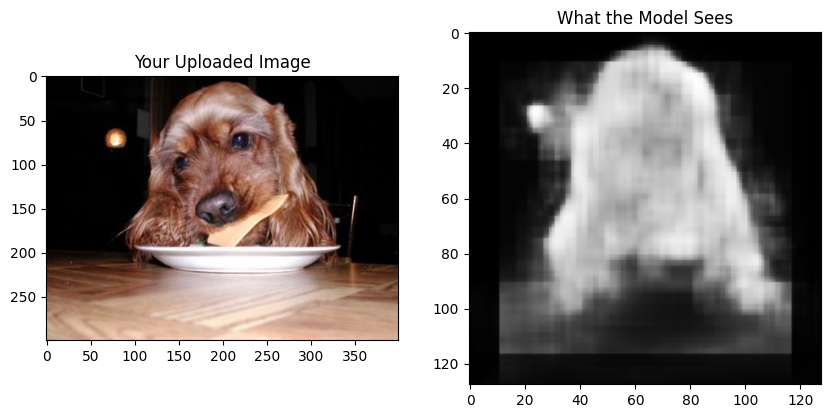

In [27]:
from google.colab import files
import cv2

# 1. Upload image
print("Select an image from your computer:")
uploaded = files.upload()

for filename in uploaded.keys():
    # 2. Load and resize it to 128x128 to match the models training
    raw_img = cv2.imread(filename)
    raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(raw_img, (128, 128)) / 255.0

    # 3. Make the prediction
    pred = model.predict(np.expand_dims(img_resized, axis=0))[0]

    # 4. Show the result
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(raw_img)
    plt.title("Your Uploaded Image")

    plt.subplot(1, 2, 2)
    plt.imshow(pred.reshape(128, 128), cmap='gray')
    plt.title("What the Model Sees")
    plt.show()

In [24]:

model.save('salient_object_model.h5')
print("Success! Your model is saved as salient_object_model.h5")

Success! Your model is saved as salient_object_model.h5
